Some events form in different astrophysical environments than others. **You want to figure out how many of formation channels are at play.**


The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability.


*Note*. We'll do a more formal introduction to scikit-learn in one of the next lectures. Today's exercise is meant to be a formative example on how you might find yourself dealing with a library you've never seen before. This happens *all the time* in research...





In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats

#### Tasks

1) Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?


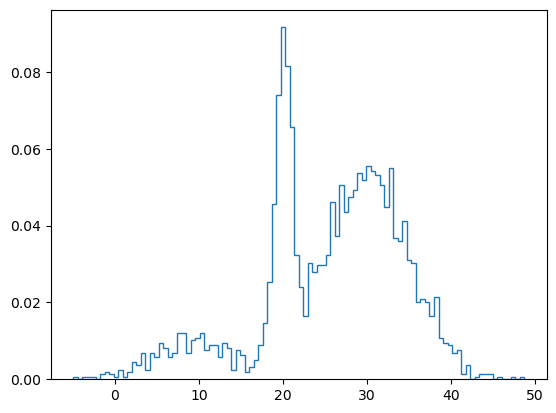

In [2]:
file = np.load('formationchannels.npy')
plt.hist(file,bins=100, density= True, histtype= 'step');
# We found 3 bumps

2) We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

**THIS PART IS THE BASICS OF `GaussianMixture` code**

In [3]:
n = 3
np.random.seed(42)
gm = GaussianMixture(n_components=n ) # you have created instance of 3 components of a gaussian model
fit = gm.fit(file)   # trained model, you can extract: 
print(fit.means_) # The means 
print('The data weights in each component',fit.weights_,' and the sum = ' ,np.sum(fit.weights_))
print('The values of the function separation (std)',fit.covariances_) 
print(f'The values distribution in the {n} components',fit.predict(file))
print('How much is n reliable?',fit.aic(file)) # The lower the value, the better the model.

[[30.12777783]
 [20.05283694]
 [ 9.09033281]]
The data weights in each component [0.66911222 0.21467178 0.11621599]  and the sum =  1.0
The values of the function separation (std) [[[24.08835035]]

 [[ 1.14167809]]

 [[21.78098637]]]
The values distribution in the 3 components [2 2 2 ... 0 0 0]
How much is n reliable? 20083.50553692163


3) Complete the fit 10 times with $N=1,...,10$ Gaussians. 

In [4]:
N = np.arange(1,11)
gmmodels = [GaussianMixture(i).fit(file) for i in N]


4) For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

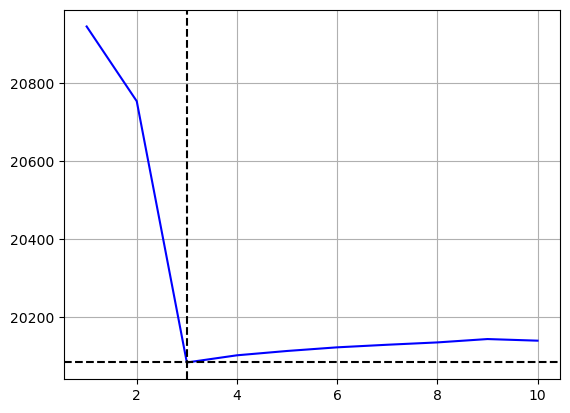

In [5]:
aic_test = [i.aic(file) for i in gmmodels]
plt.plot(N, aic_test, color = 'blue')
plt.axvline(aic_test.index(min(aic_test))+1, ls= "--", color = 'black')
plt.axhline((min(aic_test)), ls= "--", color = 'black')
plt.grid();



5) Plot the preferred solution on top of the input data. You should get a very nice fit!

In [ ]:

x = np.linspace(-5,50,1000)
log_pdf = gmmodels[2].score_samples(x.reshape(-1,1)) # .score_samples == the log of the pdf values
pdf = np.exp(log_pdf)

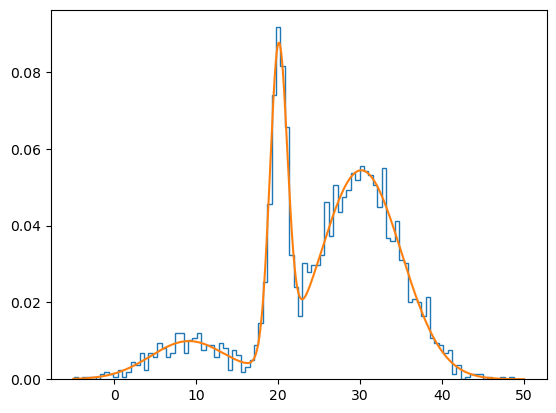

In [ ]:
fig , ax = plt.subplots()
ax.hist(file, histtype='step', bins=100, density=True);
ax.plot(x.reshape(-1,1), pdf);